In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_data():
    df = pd.read_csv("historical_prices.csv")

    df = df[df["date"] != "Ticker"]

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["close"])

    pivot = df.pivot(index="date", columns="coin_id", values="close")
    pivot = pivot.sort_index()

    returns = pivot.pct_change().dropna()

    return pivot, returns

In [3]:
def calculate_metrics(returns):

    avg_daily_return = returns.mean()
    volatility = returns.std()

    metrics = pd.DataFrame({
        "avg_daily_return": avg_daily_return,
        "volatility": volatility
    })

    metrics["annual_return"] = metrics["avg_daily_return"] * 365
    metrics["annual_volatility"] = metrics["volatility"] * np.sqrt(365)

    return metrics

In [4]:
def show_rankings(metrics):

    lowest_risk = metrics.sort_values("annual_volatility").head(1)
    highest_return = metrics.sort_values("annual_return", ascending=False).head(1)

    print("\nLowest Risk Coin:")
    print(lowest_risk)

    print("\nHighest Return Coin:")
    print(highest_return)

In [5]:
def plot_price_history(prices):

    plt.figure(figsize=(12,6))

    for coin in prices.columns:
        plt.plot(prices.index, prices[coin], label=coin)

    plt.title("1-Year Historical Price Movement")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.xticks(rotation=45)

    plt.show()

In [6]:
def plot_risk_return(metrics):

    plt.figure(figsize=(8,6))

    plt.scatter(metrics["annual_volatility"], metrics["annual_return"])

    for coin in metrics.index:
        plt.annotate(coin,
                     (metrics.loc[coin,"annual_volatility"],
                      metrics.loc[coin,"annual_return"]))

    plt.xlabel("Annual Volatility (Risk)")
    plt.ylabel("Annual Return")

    plt.title("Risk vs Return Comparison")

    plt.grid(True)
    plt.show()

In [7]:
def plot_top_coins(metrics):

    # Top 3 Highest Return
    top_return = metrics.sort_values("annual_return", ascending=False).head(3)

    # Top 3 Highest Risk
    top_risk = metrics.sort_values("annual_volatility", ascending=False).head(3)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,5))

    # Highest Return Chart
    plt.subplot(1,2,1)
    plt.bar(top_return.index, top_return["annual_return"])
    plt.title("Top 3 Highest Return Coins")
    plt.xlabel("Coin")
    plt.ylabel("Annual Return")

    # Highest Risk Chart
    plt.subplot(1,2,2)
    plt.bar(top_risk.index, top_risk["annual_volatility"])
    plt.title("Top 3 Riskiest Coins")
    plt.xlabel("Coin")
    plt.ylabel("Annual Volatility")

    plt.tight_layout()
    plt.show()


Full Metrics Table:
             avg_daily_return  volatility  annual_return  annual_volatility
coin_id                                                                    
binancecoin          0.000577    0.027912       0.210471           0.533261
bitcoin             -0.000393    0.023533      -0.143533           0.449595
cardano             -0.002411    0.043105      -0.880097           0.823514
dogecoin            -0.000976    0.047694      -0.356166           0.911193
ethereum             0.000592    0.039669       0.216057           0.757868
litecoin            -0.001018    0.037153      -0.371713           0.709810
polkadot            -0.001859    0.046586      -0.678498           0.890028
ripple              -0.000931    0.039211      -0.339974           0.749135
solana              -0.000505    0.041059      -0.184286           0.784429
tron                 0.000631    0.016984       0.230205           0.324470

Lowest Risk Coin:
         avg_daily_return  volatility  annual_re

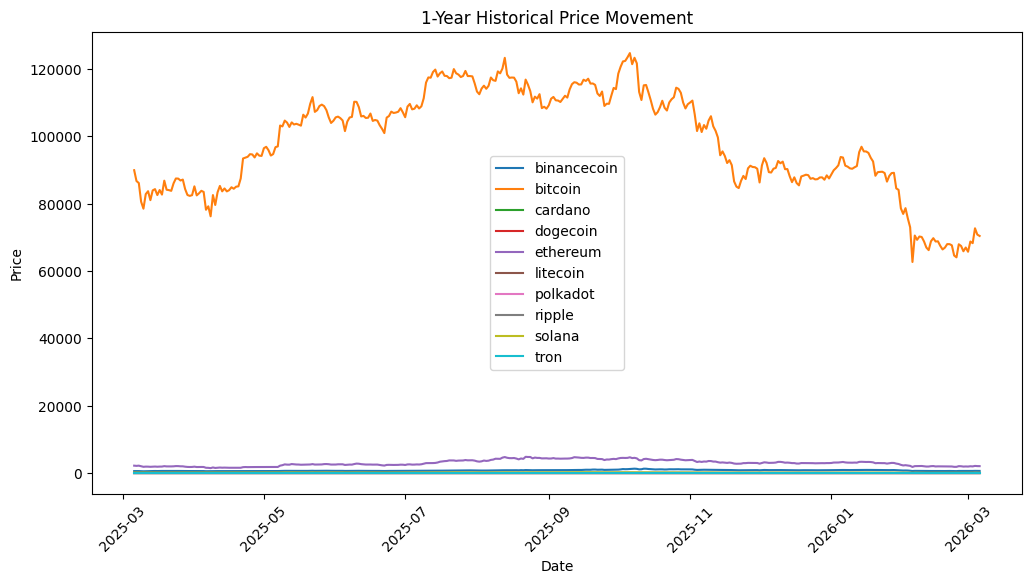

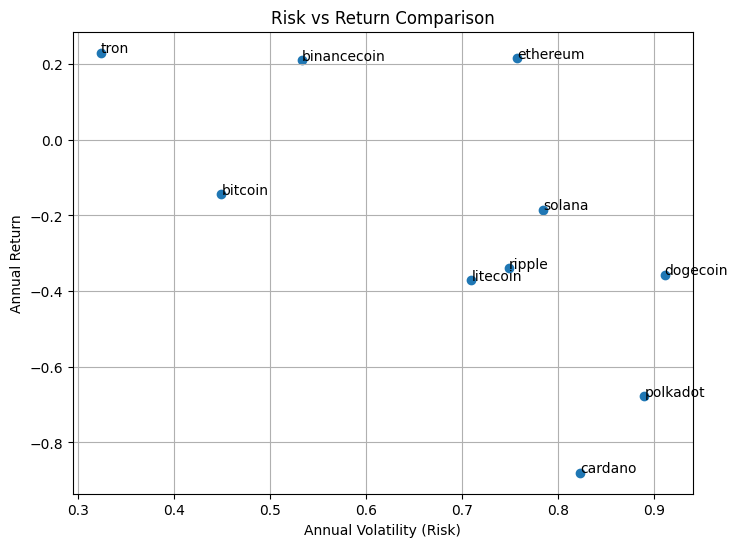

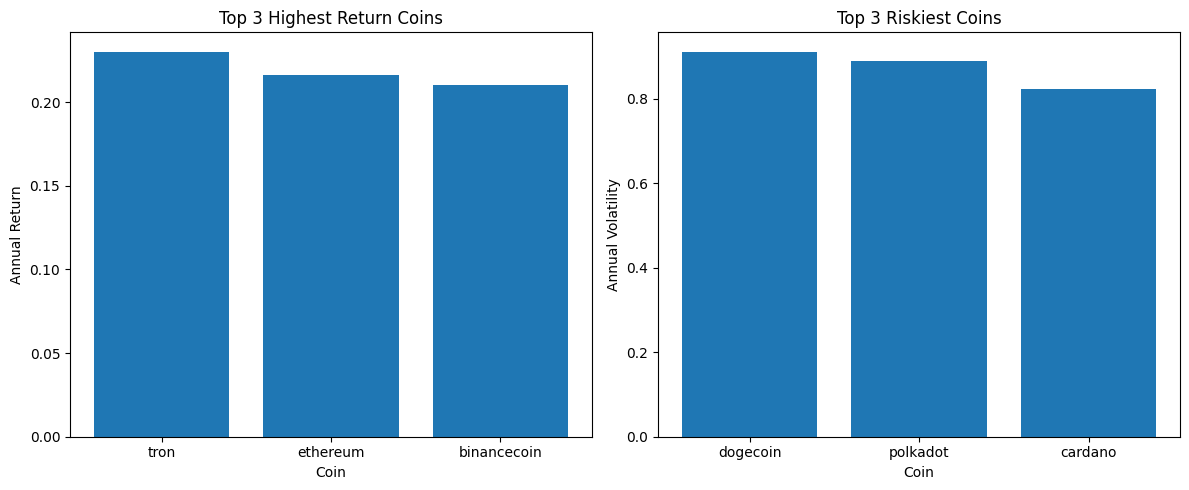

In [8]:
prices, returns = load_data()

metrics = calculate_metrics(returns)

print("\nFull Metrics Table:")
print(metrics)

show_rankings(metrics)

plot_price_history(prices)

plot_risk_return(metrics)

plot_top_coins(metrics)